In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report

from tensorflow.python import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN , Input, Flatten, LSTM, LeakyReLU
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import SGD, RMSprop, Nadam, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

2025-11-20 09:51:05.175590: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-20 09:51:05.178267: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-20 09:51:05.184310: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-20 09:51:05.199844: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763661065.224723  301095 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763661065.23

In [2]:
opened = []

masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_MONTHS_COMBINED.csv'

# Load the master list of stations
total_df = pd.read_csv(masterlist)

In [3]:
total_df = total_df[total_df['Q'] != -999]
print(f"Remaining rows: {len(total_df)}")

Remaining rows: 28486


In [4]:
print("Loaded ", len(total_df['grdc_no'].unique()), " stations.")

Loaded  564  stations.


In [8]:
from tensorflow import keras

model = keras.models.load_model(
    '/global/home/groups/fc_ecohydrology/CSMUB/CSMUB_FNN_MODEL_v2_00_11202025.keras'
)

2025-11-20 09:54:27.504396: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [9]:
# Function to calculate NSE
def nse(predictions, targets):
    return 1 - (np.sum((targets - predictions) ** 2) /
                np.sum((targets - np.mean(targets)) ** 2))

In [10]:
# Step 3: Scale the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

In [11]:
feature_columns = ['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope',
       'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9',
       'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 'LC_16', 'LC_17',
       'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5',
       'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13',
       'ST_14', 'ST_15', 'ST_16']

predict_column = 'Q'

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
-0.26098889199867537


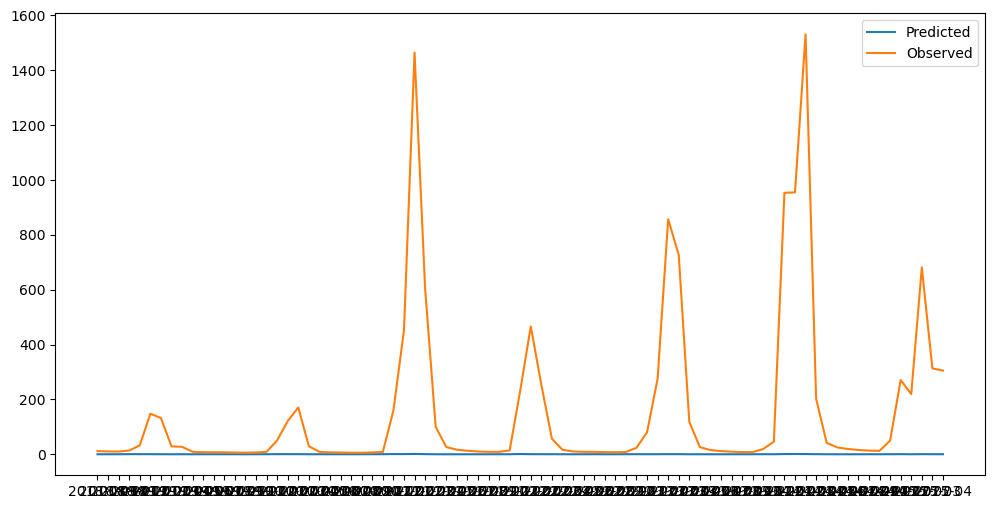

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
-0.06401116306546628


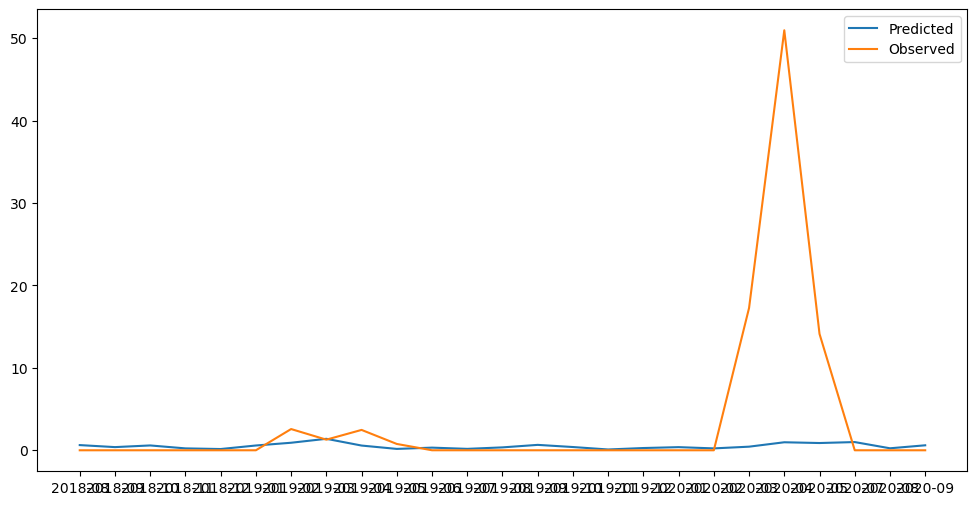

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
-0.5420655710949138


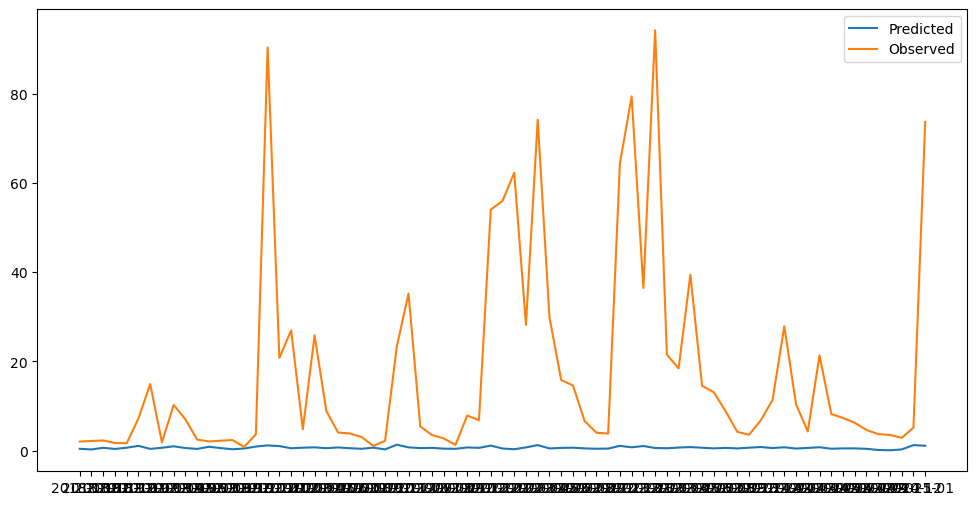

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
-2.458926245838837


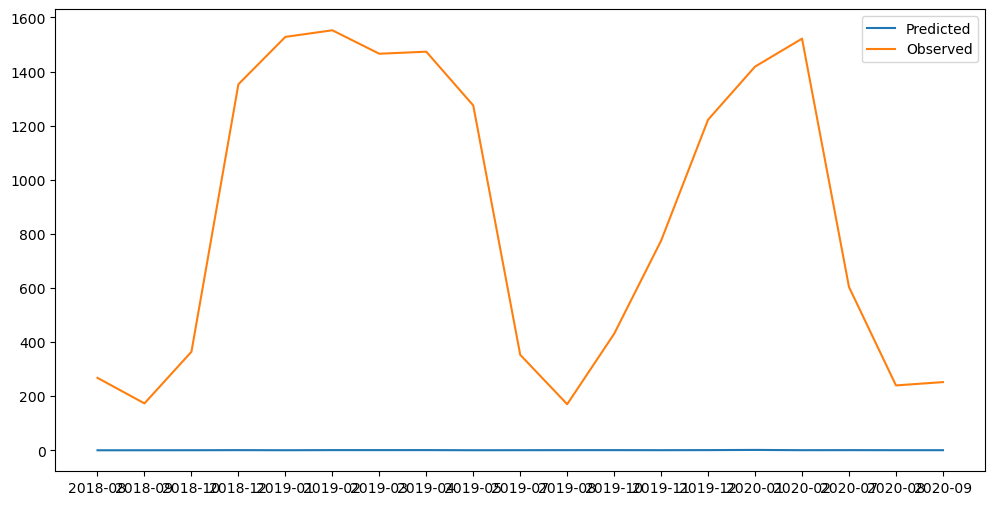

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
-0.3278122043508547


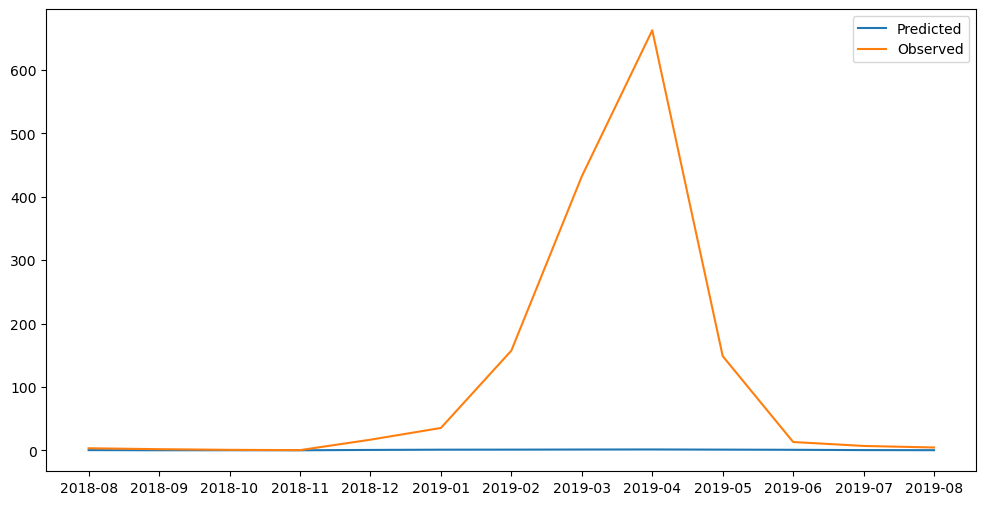

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
-1.126283468284488


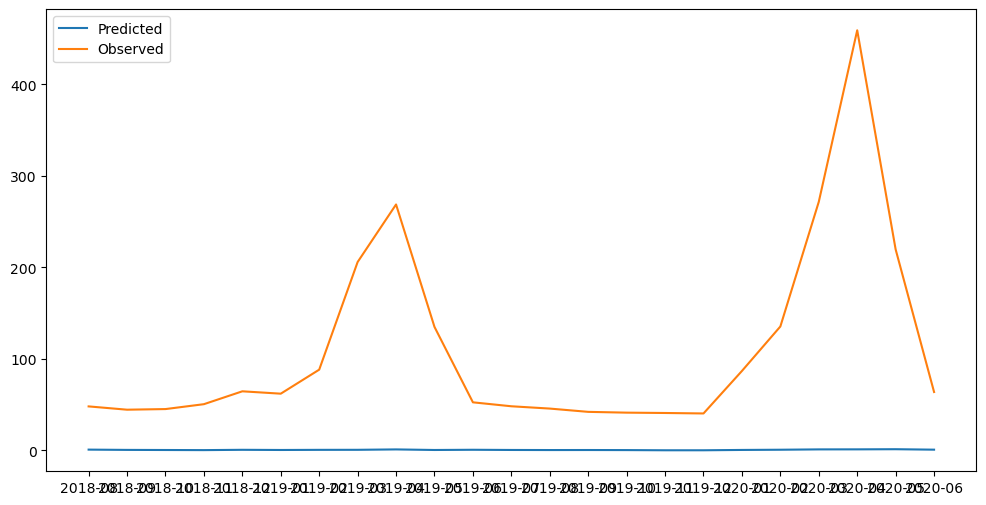

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
0.1283177555831282


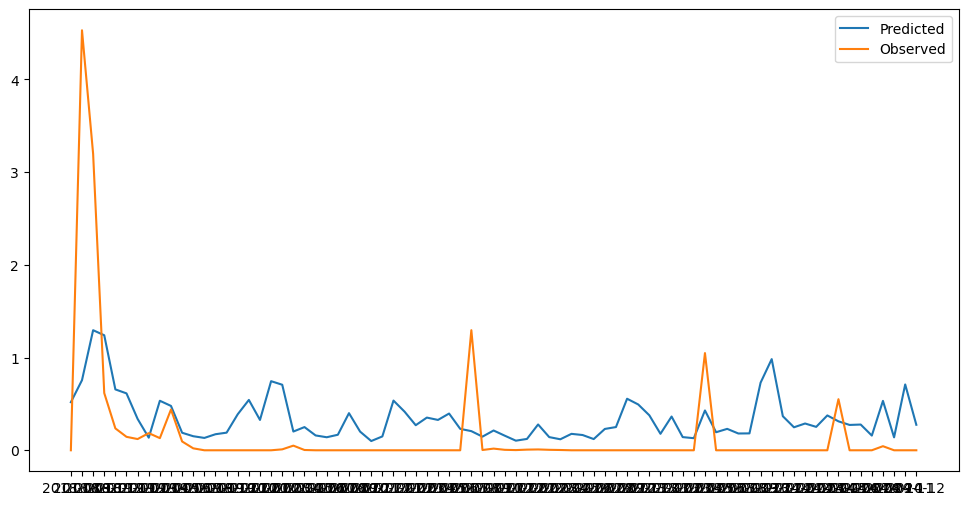

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
-0.8358724838883878


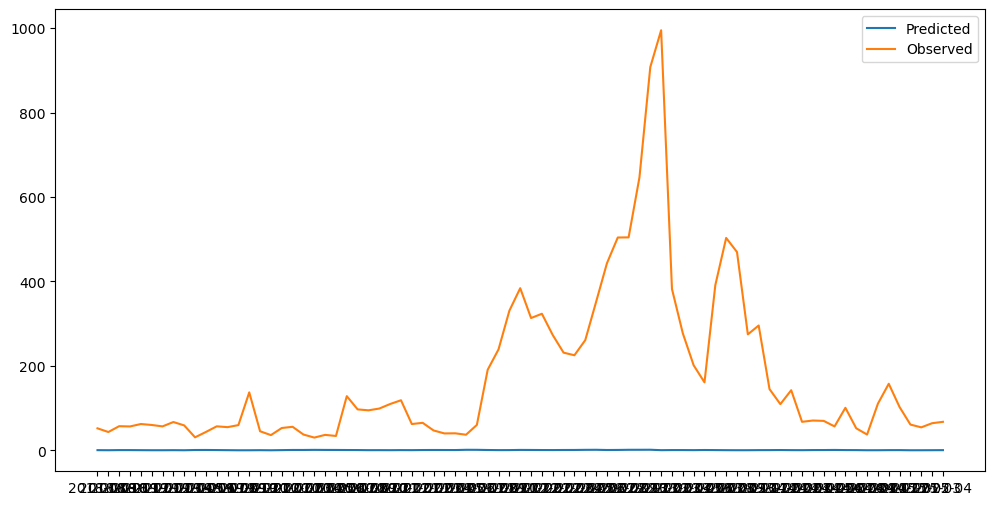

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
-0.9581955550440051


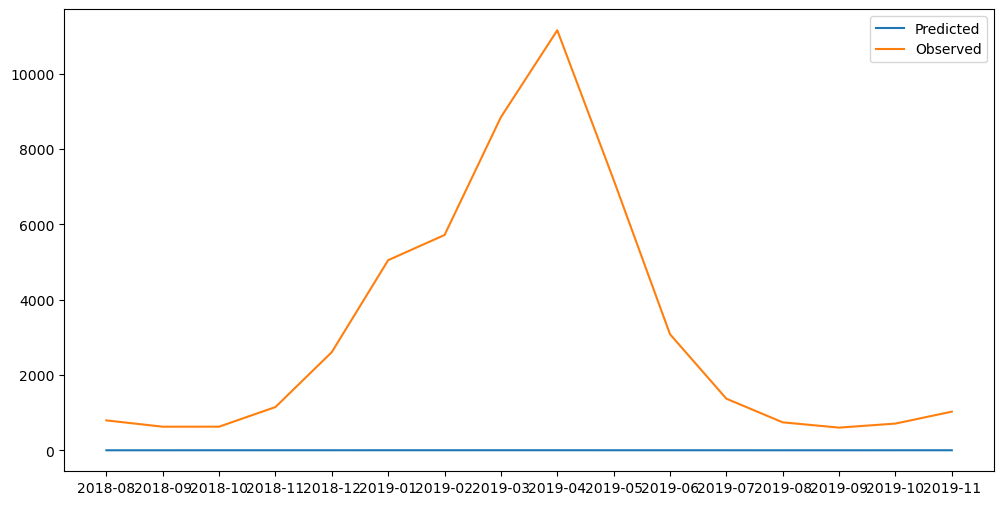

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
-2.155020150090286


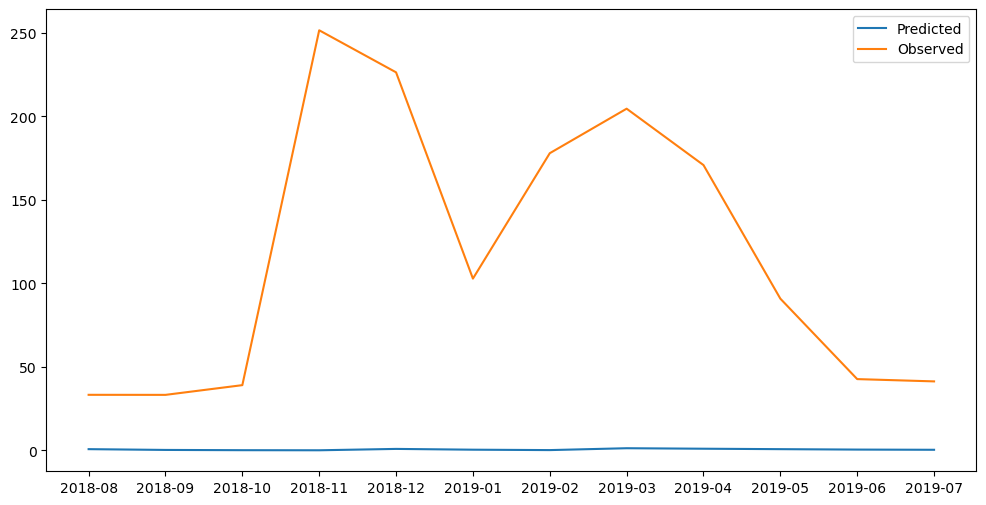

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
-0.13396025415281887


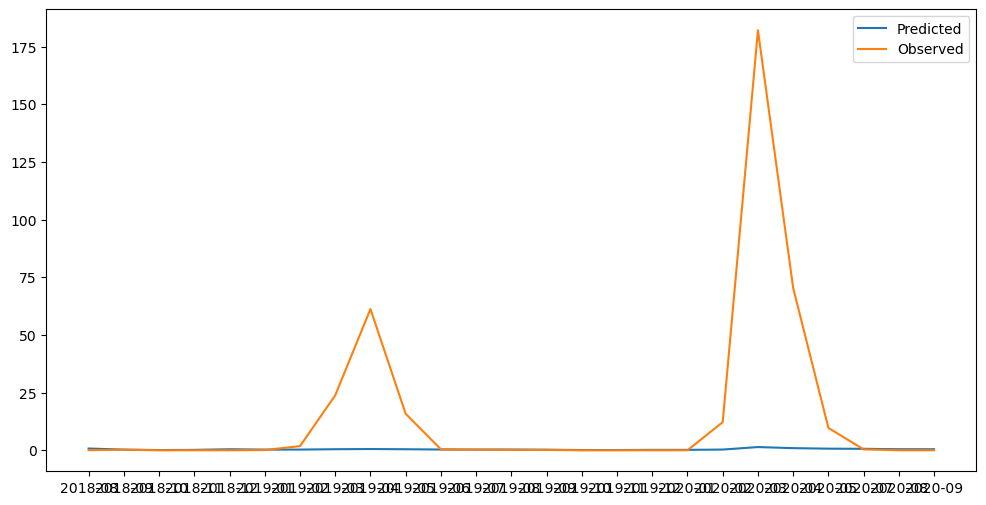

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
-0.5142946408512366


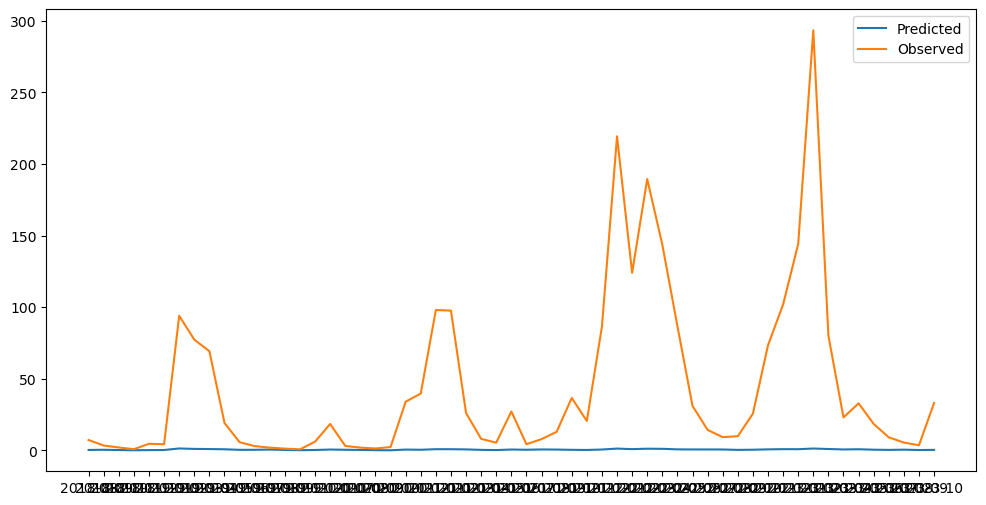

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
-1.2324223105430598


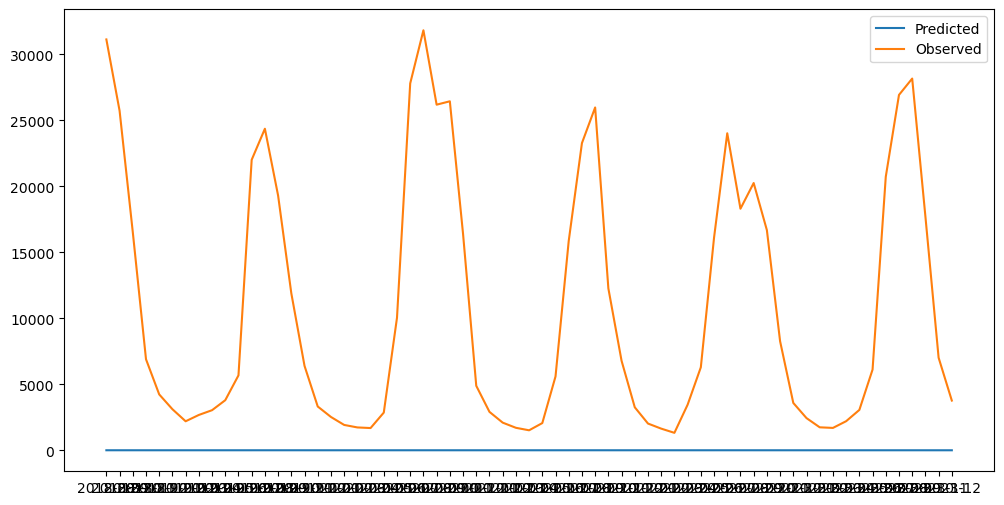

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
-1.6558061996801983


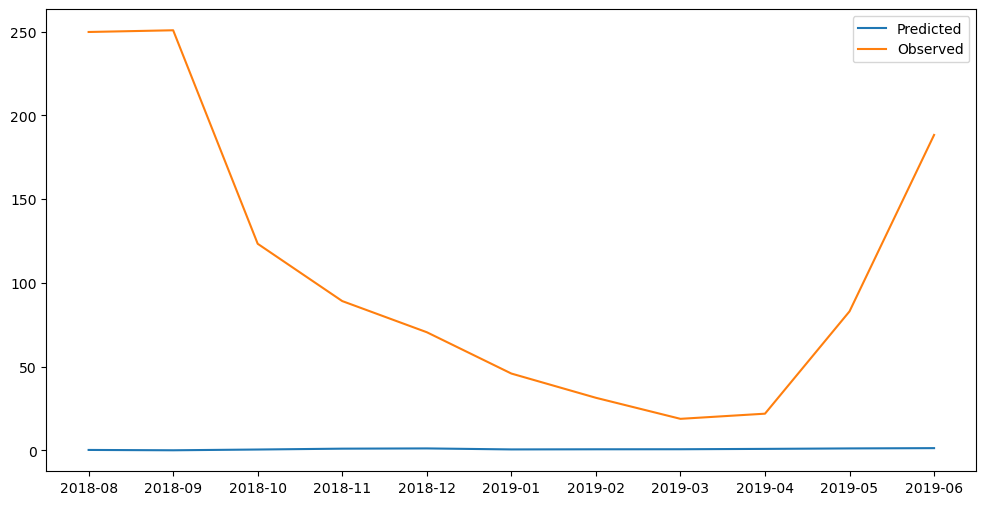

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
-2.4922441311085626


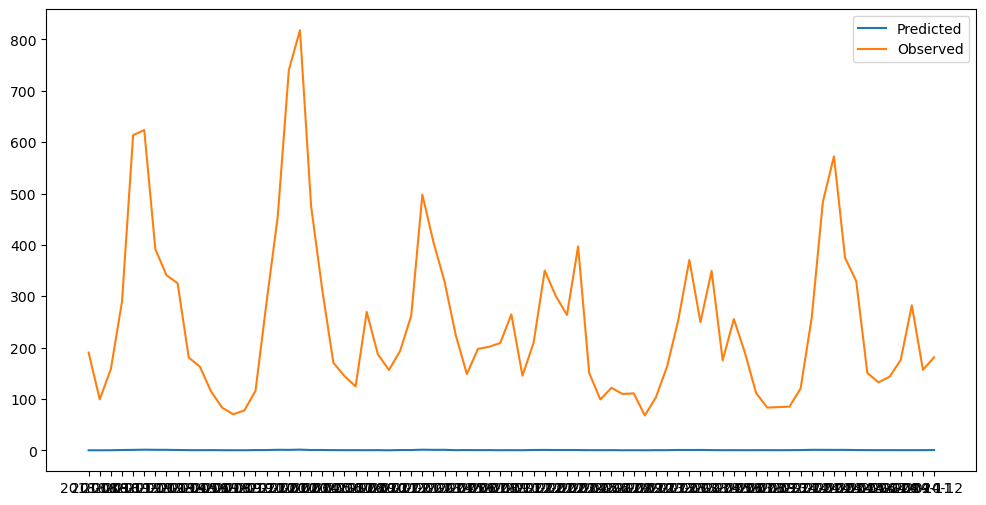

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
-2.1422927519083754


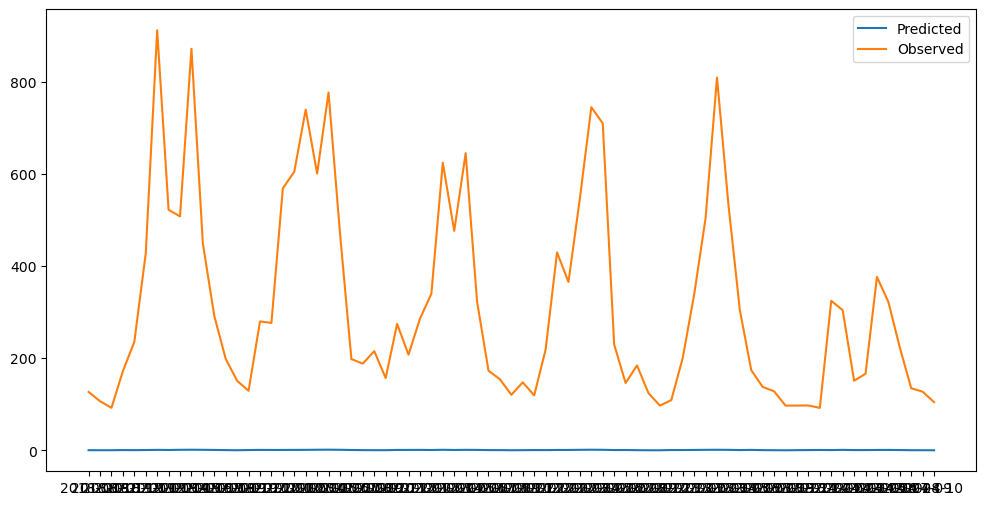

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
-2.049637108839062


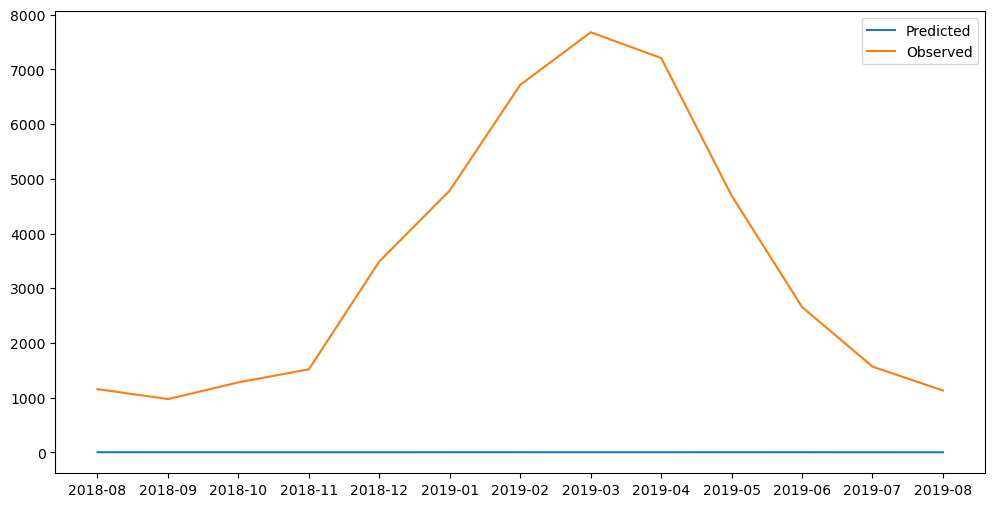

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
-0.17591343430477302


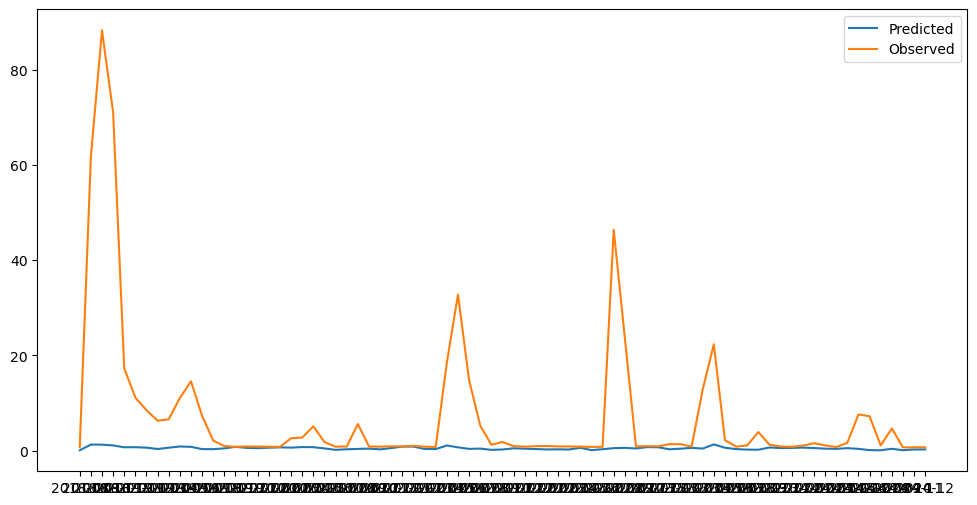

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
-0.15619018887413505


KeyboardInterrupt: 

In [18]:
# Get all unique stations
stations = total_df['grdc_no'].unique()

# Store NSE results
station_nse = []

for station_num in stations:
    subset = total_df[total_df['grdc_no'] == station_num]

    if len(subset) < 10:  # skip stations with very few observations
        continue
            
    subset = subset.sort_values("Date")

    dates = subset["Date"].copy()

    X_subset = subset[feature_columns]
    X_subset_scaled = scaler_X.fit_transform(X_subset)

    y_pred = model.predict(X_subset_scaled).flatten()

    result = subset.copy()
    result["prediction"] = y_pred

    print(nse(result["prediction"], result["Q"]))
    
    plt.figure(figsize=(12,6))
    plt.plot(result["Date"], result["prediction"], label="Predicted")
    plt.plot(result["Date"], result["Q"], label="Observed")
    plt.legend()
    plt.show()

In [ ]:
# # Get all unique stations
# stations = total_df['grdc_no'].unique()

# # Store NSE results
# station_nse = []

# for station_num in stations:
#     # Select data for this station
#     station_data = total_df[total_df['grdc_no'] == station_num]
#     if len(station_data) < 10:  # skip stations with very few observations
#         continue

#     # True Q values
#     targets = station_data['Q'].to_numpy()

#     # Input features
#     test_X = station_data.drop([
#         'Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
#         'altitude', 'Q', 'SWE','r2'
#     ], axis=1)

#     # Scale inputs
#     test_X_scaled = scaler_X.transform(test_X)

#     # Make predictions
#     test_pred = model.predict(test_X_scaled).flatten()

#     # Inverse-transform if y was scaled during training
#     test_pred_unscaled = scaler_y.inverse_transform(
#         test_pred.reshape(-1, 1)
#     ).flatten()

#     # Compute NSE
#     nse_value = nse(test_pred_unscaled, targets)

#     station_nse.append((station_num, nse_value))

# # Convert to DataFrame
# station_nse_df = pd.DataFrame(station_nse, columns=['station', 'NSE'])

# # Sort stations by NSE
# station_nse_df = station_nse_df.sort_values(by='NSE', ascending=True)

# # Show worst performing stations
# print("Stations with lowest NSE:")
# print(station_nse_df.head(10))

# # Optional: stations with NSE < 0
# poor_stations = station_nse_df[station_nse_df['NSE'] < 0]
# print("\nStations with negative NSE (predictions worse than mean):")
# print(poor_stations)